# Sampling and simulation — results visualization

This notebook visualizes outputs from the same design as [`sampling_simulation.ipynb`](sampling_simulation.ipynb), using shared logic in [`sampling_core.py`](sampling_core.py). It does **not** change estimators; it plots Monte Carlo draws, coverage, variance summaries, design effects, and sensitivity scenarios.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sampling_core import (
    build_stratum_stats,
    neyman_allocation,
    proportional_allocation,
    run_all_sensitivity_scenarios,
    run_monte_carlo,
)

RNG_SEED = 407
rng = np.random.default_rng(RNG_SEED)

DATA_PATH = "analysis_dataset.csv"
STRATA_COL = "neighbourhood"
Y_COL = "price"
OUTLIER_FLAG_COL = "price_outlier_iqr"
n_total = 300
B = 1000

METHOD_ORDER = ["SRS", "Stratified-Proportional", "Stratified-Neyman"]

df = pd.read_csv(DATA_PATH)
population = df.copy()
N = len(population)
stratum_stats = build_stratum_stats(population, strata_col=STRATA_COL, y_col=Y_COL)
alloc_prop = proportional_allocation(stratum_stats, n_total=n_total, strata_col=STRATA_COL, min_per_stratum=2)
alloc_neyman = neyman_allocation(stratum_stats, n_total=n_total, strata_col=STRATA_COL, min_per_stratum=2)

print(f"N = {N}, n = {n_total}, B = {B}, seed = {RNG_SEED}")

N = 4702, n = 300, B = 1000, seed = 407


## Monte Carlo simulation

Run **B** replications with `RNG_SEED = 407` on a **fresh** generator (this notebook does not replay the single-sample or bootstrap draws from `sampling_simulation.ipynb`). Numeric summaries may differ slightly from saved outputs in that notebook; the **qualitative** patterns (coverage, DEFF, skew of per-rep DEFF) align with the documented workflow.

In [2]:
mc_result = run_monte_carlo(
    population,
    stratum_stats,
    alloc_prop,
    alloc_neyman,
    n_total=n_total,
    B=B,
    rng=rng,
    strata_col=STRATA_COL,
    y_col=Y_COL,
)
true_mean = mc_result.true_mean
mc = mc_result.mc
mc_summary = mc_result.mc_summary
deff_rep = mc_result.deff_rep

mc_summary_ord = mc_summary.set_index("method").reindex(METHOD_ORDER).reset_index()
print(f"True finite-population mean: {true_mean:.4f}")
mc_summary_ord

True finite-population mean: 219.7561


,method,empirical_var,avg_theoretical_var,coverage_95,mean_estimate,DEFF_emp,n_eff_DEFF_emp
0,SRS,1340.991112,1301.351283,0.774,219.661280,1.000000,300.000000
1,Stratified-Proportional,1194.914932,1190.373318,0.743,217.033110,0.891068,336.674455
2,Stratified-Neyman,628.197740,604.313621,0.844,218.808993,0.468458,640.399205


### Sampling distributions of the point estimates

Overlapping histograms show how each design’s estimator varies across replications; the vertical line is the **true** finite-population mean.

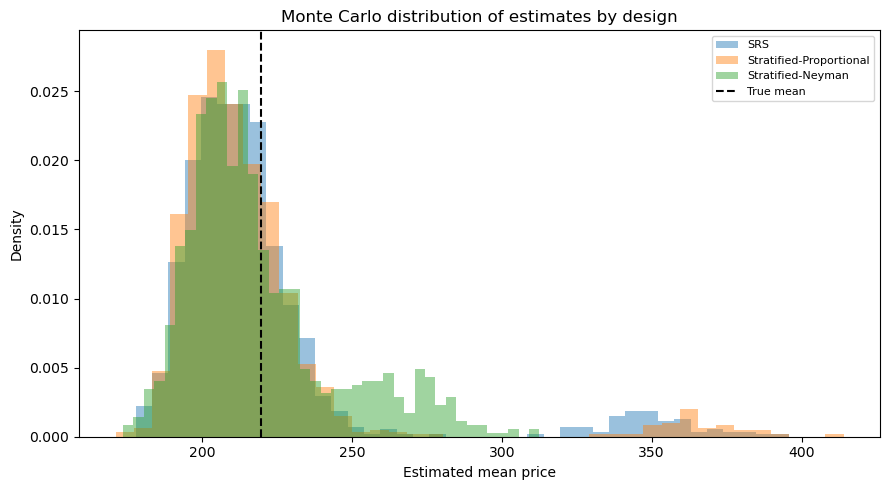

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {"SRS": "#1f77b4", "Stratified-Proportional": "#ff7f0e", "Stratified-Neyman": "#2ca02c"}
for m in METHOD_ORDER:
    x = mc.loc[mc["method"] == m, "estimate"]
    ax.hist(x, bins=40, alpha=0.45, label=m, color=colors[m], density=True)
ax.axvline(true_mean, color="black", linestyle="--", linewidth=1.5, label="True mean")
ax.set_xlabel("Estimated mean price")
ax.set_ylabel("Density")
ax.set_title("Monte Carlo distribution of estimates by design")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

Boxplots summarize spread and outliers in the same draws.

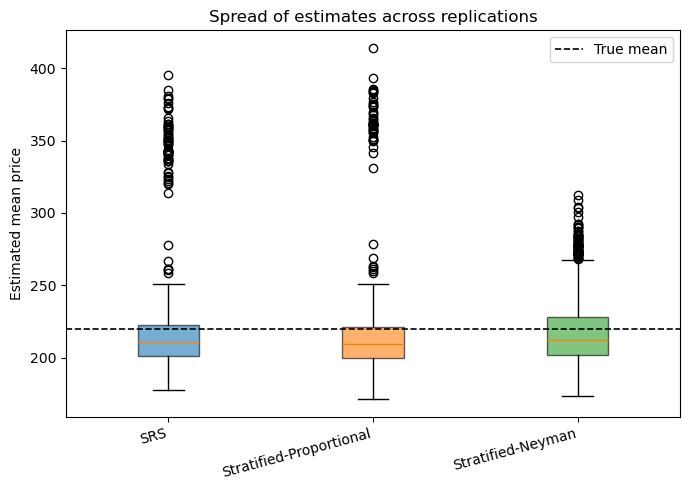

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
data = [mc.loc[mc["method"] == m, "estimate"].to_numpy() for m in METHOD_ORDER]
bp = ax.boxplot(data, tick_labels=METHOD_ORDER, patch_artist=True)
for patch, m in zip(bp["boxes"], METHOD_ORDER):
    patch.set_facecolor(colors[m])
    patch.set_alpha(0.6)
ax.axhline(true_mean, color="black", linestyle="--", linewidth=1.2, label="True mean")
ax.set_ylabel("Estimated mean price")
ax.set_title("Spread of estimates across replications")
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Confidence interval coverage

Nominal **95%** **t**-intervals are compared to the **empirical** fraction of intervals that contain the true finite-population mean. Heavy-tailed prices often pull coverage **below** 0.95 even when variance formulas are correct.

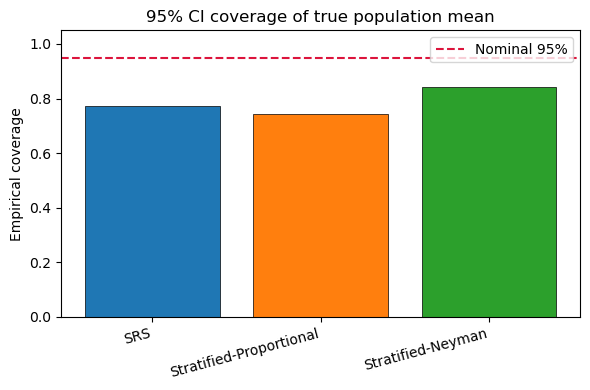

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
cov = mc_summary_ord.set_index("method")["coverage_95"].reindex(METHOD_ORDER)
ax.bar(METHOD_ORDER, cov, color=[colors[m] for m in METHOD_ORDER], edgecolor="black", linewidth=0.5)
ax.axhline(0.95, color="crimson", linestyle="--", label="Nominal 95%")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Empirical coverage")
ax.set_title("95% CI coverage of true population mean")
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Empirical vs average theoretical variance

Across replications, **empirical variance** of the point estimate is compared to the **mean** of the usual variance estimators $\widehat{V}$.

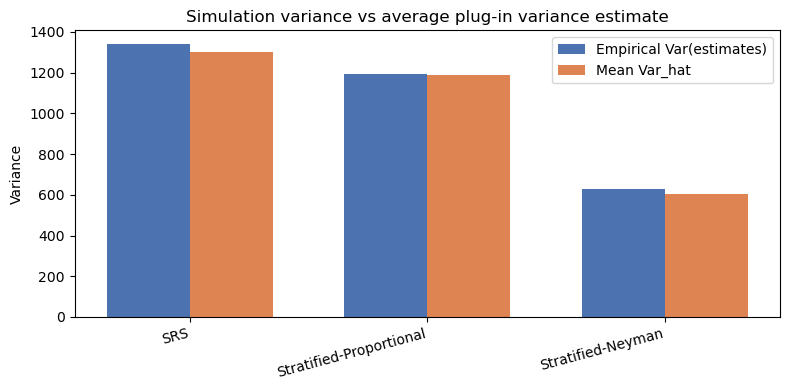

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(METHOD_ORDER))
w = 0.35
emp = mc_summary_ord["empirical_var"].to_numpy()
theo = mc_summary_ord["avg_theoretical_var"].to_numpy()
ax.bar(x - w / 2, emp, width=w, label="Empirical Var(estimates)", color="#4c72b0")
ax.bar(x + w / 2, theo, width=w, label="Mean Var_hat", color="#dd8452")
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER, rotation=15, ha="right")
ax.set_ylabel("Variance")
ax.set_title("Simulation variance vs average plug-in variance estimate")
ax.legend()
plt.tight_layout()
plt.show()

### Design effect (empirical) and per-replication $\widehat{\mathrm{DEFF}}_b$

**DEFF_emp** is the ratio of **empirical** variances (complex vs SRS). Per-replication ratios $\widehat{V}_{\mathrm{strat}}/\widehat{V}_{\mathrm{SRS}}$ are **heavily right-skewed**; the histogram uses a **log** scale on the x-axis for readability.

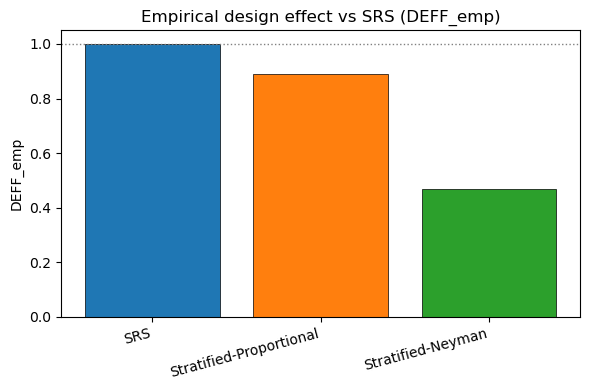

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
deff_emp = mc_summary_ord.set_index("method")["DEFF_emp"].reindex(METHOD_ORDER)
ax.bar(METHOD_ORDER, deff_emp, color=[colors[m] for m in METHOD_ORDER], edgecolor="black", linewidth=0.5)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
ax.set_ylabel("DEFF_emp")
ax.set_title("Empirical design effect vs SRS (DEFF_emp)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

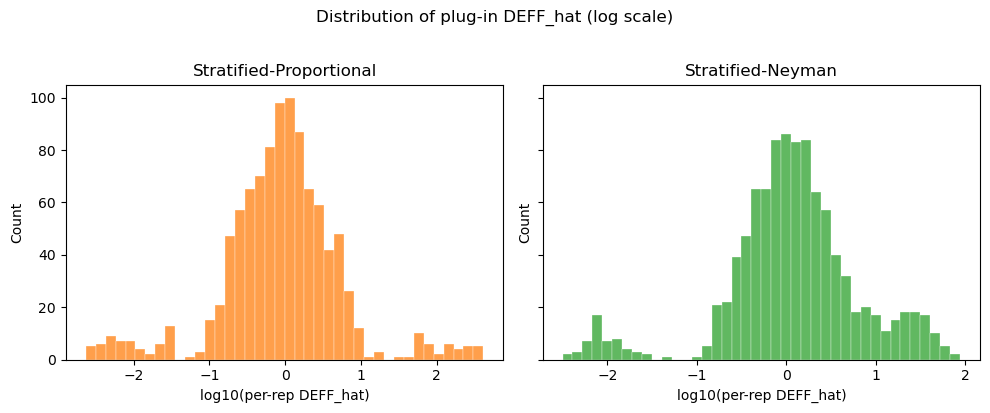

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, col in zip(axes, ["Stratified-Proportional", "Stratified-Neyman"]):
    s = deff_rep[col].dropna()
    s = s[s > 0]
    ax.hist(np.log10(s), bins=40, color=colors[col], alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.set_xlabel("log10(per-rep DEFF_hat)")
    ax.set_ylabel("Count")
    ax.set_title(col)
plt.suptitle("Distribution of plug-in DEFF_hat (log scale)", y=1.02)
plt.tight_layout()
plt.show()

### Sensitivity analysis

One **n=300** draw per scenario (same RNG stream after Monte Carlo): main population, price capped at $5000, and exclusion of IQR-flagged price outliers.

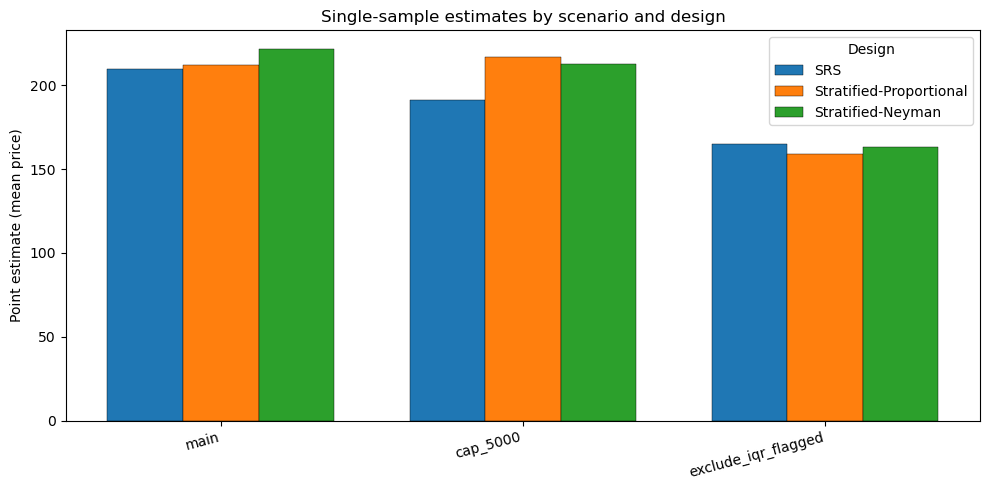

In [9]:
sens = run_all_sensitivity_scenarios(
    population,
    rng,
    n_total=n_total,
    y_col=Y_COL,
    strata_col=STRATA_COL,
    outlier_flag_col=OUTLIER_FLAG_COL,
)
sens

scenario_order = ["main", "cap_5000", "exclude_iqr_flagged"]

fig, ax = plt.subplots(figsize=(10, 5))
n_sc = len(scenario_order)
x = np.arange(n_sc)
w = 0.25
for i, m in enumerate(METHOD_ORDER):
    vals = [float(sens.loc[(sens["scenario"] == sc) & (sens["method"] == m), "estimate"].iloc[0]) for sc in scenario_order]
    ax.bar(x + (i - 1) * w, vals, width=w, label=m, color=colors[m], edgecolor="black", linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels(scenario_order, rotation=15, ha="right")
ax.set_ylabel("Point estimate (mean price)")
ax.set_title("Single-sample estimates by scenario and design")
ax.legend(title="Design")
plt.tight_layout()
plt.show()

### Takeaways

- The **true** quantity is the **finite-population** mean; all designs are **approximately unbiased** (mean estimate near the true mean), but **precision** differs: **Neyman** stratification often achieves **DEFF_emp < 1** here, while **proportional** stratification can be **worse than SRS** on variance depending on stratum homogeneity.
- **Coverage** below the nominal 0.95 is consistent with **skewed** nightly prices: standard **t** intervals assume approximate normality of the sample mean; the bootstrap diagnostic in the main notebook shows the same pattern.
- **Per-replication DEFF_hat** can spike when $\widehat{V}_{\mathrm{SRS}}$ is small in a given draw; summarize with **DEFF_emp** or **medians**, not only the mean of ratios.
- **Sensitivity** plots show how **capping** or **trimming outliers** shifts levels and can **stabilize** variance (compare SEs in the printed table).